# 1. Frame the Problem


1. Binary Classification

The primary task of this model is Binary Classification. Given a set of player statistics, the model predicts will classify a player as either an AllStar (1) or not (0). Because the number of AllStar roster spots is fixed each season, this project utilizes a ranking approach, where the model ranks all active players by their predicited probability and then selects the top K players (depending on how many All stars there were that season) as AllStars. 

2. Real World Practical Purpose

NBA All Star selections significantly impact player contract incentives, Hall of Fame elgibility, trade value, and overall popularity. However, the selection process involves fan, media, and player voting which can often be influenced by human bias. Some of these biases include : 

* Players in larger markets like LA receive more visibility
* Legacy bias: Older stars may receive more votes than younger players
* Injury Replacement players are chosen by the commisioner and may not allign with statistical output

The purpose of this model is to provide an objective benchmark for All Star caliber performance. By training on over 40 years of data, the model can identify which player statistically earned a spot on the team. 


# 2. Get the Data

Dataset downloaded from Kaggle. 
- [NBA Data](https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats)

These csv files contain personal statistics for every player from the beginning of the NBA tracking data to the present. The user who provides these datasets claims to have scraped it from BasketballReference and compiled them together into multiple different files. 

We will be using 3 of these files : Player Totals.csv, Advanced.csv, and All-Star Selections.csv

###  Import the Dataset

In [140]:
import numpy as np
import pandas as pd

In [141]:
# Show all columns in the DataFrame
pd.set_option('display.max_columns', None)

In [142]:
# Insert Dataset Here )
df = pd.read_csv("..//datasets//player_stats_all_time.csv")
all_star = pd.read_csv("..//datasets//AllStar_selections.csv")
advanced_stats = pd.read_csv("..//datasets//Advanced.csv")

# 3. Exploring the Data

In [143]:
df.head()

,season,lg,player,player_id,age,team,pos,g,gs,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,e_fg_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,26,13.0,19.8,3.0,6.0,0.497,0.3,0.9,0.292,2.7,5.0,0.534,0.519,0.9,2.0,0.471,1.9,3.5,5.4,1.1,0.8,0.4,0.4,1.7,7.1
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,25,7.0,21.7,2.2,4.4,0.491,0.0,0.0,NaN,2.2,4.4,0.491,0.491,1.6,2.5,0.651,4.4,4.1,8.4,1.4,0.7,0.6,1.1,1.8,6.0
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,25,25.0,31.0,6.4,13.8,0.467,1.4,4.3,0.318,5.1,9.5,0.534,0.516,3.5,4.6,0.759,1.6,7.9,9.5,2.5,1.0,0.8,1.9,1.8,17.8
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,27,11.0,16.7,1.9,4.4,0.424,0.3,1.5,0.175,1.6,2.9,0.551,0.453,0.7,0.8,0.857,0.7,1.7,2.4,0.9,0.5,0.2,0.3,2.0,4.6
4,2026,NBA,Santi Aldama,aldamsa01,25.0,MEM,PF,33,8.0,27.9,5.5,11.4,0.479,1.7,4.8,0.352,3.8,6.6,0.571,0.553,1.7,2.5,0.675,1.5,5.2,6.7,3.0,1.0,0.7,1.4,1.5,14.3


All Star Dataset Lists all the players that were classified as AllStars from each NBA season. 

We will merge this dataset with our stats dataset later and have this be our target variable. 

In [144]:
all_star.head()

,player,player_id,team,season,lg,replaced
0,Scottie Barnes,barnesc01,Team Stars,2026,NBA,False
1,Devin Booker,bookede01,Team Stars,2026,NBA,False
2,Cade Cunningham,cunnica01,Team Stars,2026,NBA,False
3,Jalen Duren,durenja01,Team Stars,2026,NBA,False
4,Anthony Edwards,edwaran01,Team Stars,2026,NBA,False


In [145]:
advanced_stats.head()

,season,lg,player,player_id,age,team,pos,g,gs,mp,per,ts_percent,x3p_ar,f_tr,orb_percent,drb_percent,trb_percent,ast_percent,stl_percent,blk_percent,tov_percent,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,73,57.0,1745.0,16.2,0.558,0.162,0.232,11.0,20.8,15.8,8.5,1.8,2.6,9.0,17.6,1.8,1.2,2.9,0.081,-0.5,-1.1,-1.6,0.2
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,730.0,15.8,0.535,0.000,0.583,22.3,19.6,21.0,8.3,1.5,2.5,16.7,12.1,1.1,1.0,2.1,0.141,-0.1,-0.3,-0.5,0.3
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,73,73.0,2365.0,18.7,0.551,0.349,0.369,6.5,25.7,16.1,14.1,1.7,1.8,8.3,25.0,2.8,3.6,6.4,0.129,1.5,0.4,2.0,2.4
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,2TM,SG,62,13.0,973.0,8.9,0.525,0.457,0.154,5.3,11.5,8.3,6.8,1.2,1.7,9.4,14.6,0.1,0.8,0.9,0.046,-3.5,-0.5,-4.0,-0.5
4,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,42,13.0,650.0,7.5,0.495,0.382,0.171,5.7,10.9,8.3,6.0,1.3,1.6,9.4,13.3,0.0,0.7,0.6,0.048,-4.8,0.1,-4.7,-0.5


# 4. Preparing the Data

### Look for Data that Needs to Be Dropped / Cleaned

In [146]:
# Drop Rows with NaN values 
print(f"Number of rows before dropping NaN values: {len(df)}")
df.dropna(inplace=True)

# Drop Columns with NaN values 
df.dropna(axis=1, inplace=True, how = "all")
print(f"Number of rows after dropping NaN values: {len(df)}")

Number of rows before dropping NaN values: 33119
Number of rows after dropping NaN values: 20173


#### Drop duplicate players if they were traded midseason. 
In this dataset, if a player is traded their original team stats, their new team stats, and their overall stats are saved. We only want their overall season stats. 

In [147]:
display(df.query('team == "2TM"').head())

,season,lg,player,player_id,age,team,pos,g,gs,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,e_fg_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
105,2026,NBA,RayJ Dennis,dennira01,24.0,2TM,PG,14,0.0,12.3,1.6,5.1,0.306,0.9,2.7,0.316,0.7,2.4,0.294,0.389,0.6,0.6,0.889,0.6,1.1,1.6,1.9,0.2,0.3,1.1,1.1,4.6
171,2026,NBA,PJ Hall,hallpj01,23.0,2TM,C,10,0.0,6.8,1.2,2.0,0.600,0.1,0.3,0.333,1.1,1.7,0.647,0.625,0.7,1.1,0.636,0.7,1.5,2.2,0.4,0.1,0.2,0.3,0.6,3.2
237,2026,NBA,Isaac Jones,jonesis01,25.0,2TM,PF,4,1.0,4.5,0.5,1.0,0.500,0.0,0.5,0.000,0.5,0.5,1.000,0.500,0.3,0.5,0.500,0.5,0.0,0.5,0.3,0.0,0.0,0.0,1.0,1.3
523,2025,NBA,Kyle Anderson,anderky01,31.0,2TM,PF,61,4.0,16.4,2.3,5.0,0.469,0.4,1.1,0.357,1.9,3.8,0.502,0.510,0.8,1.1,0.738,0.9,2.5,3.4,2.4,0.7,0.5,0.6,1.3,5.9
532,2025,NBA,Marvin Bagley III,baglema01,25.0,2TM,PF,31,2.0,8.5,1.8,3.4,0.519,0.1,0.6,0.158,1.7,2.8,0.598,0.533,0.7,1.1,0.657,1.2,1.5,2.7,0.4,0.3,0.3,0.4,0.6,4.4


In [148]:
# Drop duplicates if a player was traded midseason. We only keep total season stats. 

df = (
    df 
    .sort_values(by=['season','player_id', 'g'], ascending=[False, True, False]) #puts highest row up top, which would be 2tm or 3tm or whatever
    .drop_duplicates(subset=['player_id', 'season'], keep='first') # Drop duplicates
)

advanced_stats = (
    advanced_stats 
    .sort_values(by=['season','player_id', 'g'], ascending=[False, True, False]) #puts highest row up top, which would be 2tm or 3tm or whatever
    .drop_duplicates(subset=['player_id', 'season'], keep='first') # Drop duplicates
)



## Combine or Add Data


Some stats were not being tracked in the infancy of the league, such as rebounds, steals, blocks and 3 pointers since the line did not exist until 1979. Most importantly, AllStar selections. We will keep data from 1979 and onward. 

In [149]:

all_star = all_star[all_star['season'] >= 1979]  # All-Star data starts from 1973, but 3pt added 1979
# We will also limit the advanced stats dataset to after 1979 to match the All-Star dataset and because the game changed significantly after the 3pt line was added.
advanced_stats = advanced_stats[advanced_stats['season'] >= 1979] 


#### Adding All Star selection column at end to predict. 
Combining the All Star Selection dataset with our main dataset here. 
A 1 indicates an All Star selection, while a 0 indicates they were not selected. The number of all star selections per year varies due to injuries, but usually is around 24-28. 

In [150]:
# Adding column to indicate if player was an All-Str that season. 1 indicates All-Star selection, 0 indicates no selection.
from unicodedata import name


df['AllStar'] = np.where(df[['player_id', 'season']].apply(tuple, axis=1).isin(all_star[['player_id', 'season']].apply(tuple, axis=1)), 1, 0)

# Showw all All-Stars from 2020 season to verify the new column is correct.
display(
    df
    .query("season == 2020 and AllStar == 1")
)

,season,lg,player,player_id,age,team,pos,g,gs,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,e_fg_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,AllStar
4180,2020,NBA,Bam Adebayo,adebaba01,22.0,MIA,PF,72,72.0,33.6,6.1,11.0,0.557,0.0,0.2,0.143,6.1,10.8,0.564,0.558,3.7,5.3,0.691,2.4,7.8,10.2,5.1,1.1,1.3,2.8,2.5,15.9,1
4191,2020,NBA,Giannis Antetokounmpo,antetgi01,25.0,MIL,PF,63,63.0,30.4,10.9,19.7,0.553,1.4,4.7,0.304,9.5,15.0,0.631,0.589,6.3,10.0,0.633,2.2,11.4,13.6,5.6,1.0,1.0,3.7,3.1,29.5,1
4247,2020,NBA,Devin Booker,bookede01,23.0,PHO,SG,70,70.0,35.9,9.0,18.3,0.489,2.0,5.7,0.354,6.9,12.6,0.549,0.544,6.7,7.3,0.919,0.4,3.8,4.2,6.5,0.7,0.3,3.8,3.0,26.6,1
4278,2020,NBA,Jimmy Butler,butleji01,30.0,MIA,SF,58,58.0,33.8,5.9,13.1,0.455,0.5,2.1,0.244,5.4,11.0,0.495,0.474,7.6,9.1,0.834,1.8,4.8,6.7,6.0,1.8,0.6,2.2,1.4,19.9,1
4341,2020,NBA,Anthony Davis,davisan02,26.0,LAL,PF,62,62.0,34.4,8.9,17.7,0.503,1.2,3.5,0.330,7.7,14.2,0.546,0.536,7.2,8.5,0.846,2.3,7.0,9.3,3.2,1.5,2.3,2.5,2.5,26.1,1
4356,2020,NBA,Luka Dončić,doncilu01,20.0,DAL,PG,61,61.0,33.6,9.5,20.6,0.463,2.8,8.9,0.316,6.7,11.7,0.574,0.531,7.0,9.2,0.758,1.3,8.1,9.4,8.8,1.0,0.2,4.3,2.5,28.8,1
4370,2020,NBA,Joel Embiid,embiijo01,25.0,PHI,C,51,51.0,29.5,7.5,15.7,0.477,1.1,3.4,0.331,6.4,12.3,0.517,0.512,6.9,8.5,0.807,2.8,8.9,11.6,3.0,0.9,1.3,3.1,3.4,23.0,1
4436,2020,NBA,James Harden,hardeja01,30.0,HOU,SG,68,68.0,36.5,9.9,22.3,0.444,4.4,12.4,0.355,5.5,9.9,0.556,0.543,10.2,11.8,0.865,1.0,5.5,6.6,7.5,1.8,0.9,4.5,3.3,34.3,1
4486,2020,NBA,Brandon Ingram,ingrabr01,22.0,NOP,PF,62,62.0,33.9,8.2,17.7,0.463,2.4,6.2,0.391,5.8,11.5,0.501,0.531,5.0,5.9,0.851,0.8,5.3,6.1,4.2,1.0,0.6,3.0,2.9,23.8,1
4498,2020,NBA,LeBron James,jamesle01,35.0,LAL,PG,67,67.0,34.6,9.6,19.4,0.493,2.2,6.3,0.348,7.4,13.1,0.564,0.550,3.9,5.7,0.693,1.0,6.9,7.8,10.2,1.2,0.5,3.9,1.8,25.3,1


# 5. Training the Model
#### Random Forest
We will build the model on all data prior to 2026 and attempt to predict the allstars for 2026

In [151]:
features = df.drop(columns = ['season', 'lg', 'player_id', 'player', 'team', 'pos', 'AllStar']).columns

train_df = df[(df['season'] <= 2025) & (df['season'] >= 1980)]
X_train = train_df[features]
y_train = train_df['AllStar']

test_2026_df = df[df['season'] == 2026]
X_test_2026 = test_2026_df[features]
y_test_2026 = test_2026_df['AllStar']

We chose to use A Random Forest Classifier firstly because we have an unbalanced dataset, where only about 24-28 players out of over 400 are chosen as allstars. This model tends to be less prone to overfitting compared to single decision trees. It can also capture the interactions between all the different types of stats we have that linear models cannot. 

In [152]:
from sklearn.ensemble import RandomForestClassifier

model_first = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 5,
    random_state=42,
)

model_first.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [153]:
from sklearn.metrics import f1_score
probs = model_first.predict_proba(X_test_2026)[:, 1]

# Attach to results for 2026
results_2026 = test_2026_df[['player', 'AllStar']].copy()
results_2026['Prob'] = probs

# Sort and pick the Top 24
results_2026 = results_2026.sort_values(by='Prob', ascending=False)
results_2026['Predicted_AllStar'] = 0

# Count how many actual All-Stars there are in 2026, and that is how many AllStars our model will predict. This way our predictions are directly comparable to the actuals, since we know there are 24 All-Stars each season before replacement. 
actual_all_stars_2026_count = results_2026['AllStar'].sum()

results_2026.iloc[:actual_all_stars_2026_count, results_2026.columns.get_loc('Predicted_AllStar')] = 1

f1 = f1_score(results_2026['AllStar'], results_2026['Predicted_AllStar'])
print(f"F1 Score for 2026 predictions: {f1:.4f}")



F1 Score for 2026 predictions: 0.7407


# 6. Fine Tuning the Model

### Added Features to Improve Model

New Feature Added (VORP, Usage Percentage, and Win Shares per 48 minutes)

We are combining some of our data here by adding some advanced stats that we deem important. Some other stats are important as well, but they are calculated with basic stats so we will let the model do its work. 

In [154]:

df = df.merge(advanced_stats[['player_id', 'season', 'vorp', 'usg_percent', 'ws_48']], 
              on=['player_id', 'season'], 
              how='left')

# fill NaNs with 0 for the ML model
df[['vorp', 'usg_percent', 'ws_48']] = df[['vorp', 'usg_percent', 'ws_48']].fillna(0)
df.head()

,season,lg,player,player_id,age,team,pos,g,gs,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,e_fg_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,AllStar,vorp,usg_percent,ws_48
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,26,13.0,19.8,3.0,6.0,0.497,0.3,0.9,0.292,2.7,5.0,0.534,0.519,0.9,2.0,0.471,1.9,3.5,5.4,1.1,0.8,0.4,0.4,1.7,7.1,0,0.2,17.6,0.081
1,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,25,25.0,31.0,6.4,13.8,0.467,1.4,4.3,0.318,5.1,9.5,0.534,0.516,3.5,4.6,0.759,1.6,7.9,9.5,2.5,1.0,0.8,1.9,1.8,17.8,0,2.4,25.0,0.129
2,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,27,11.0,16.7,1.9,4.4,0.424,0.3,1.5,0.175,1.6,2.9,0.551,0.453,0.7,0.8,0.857,0.7,1.7,2.4,0.9,0.5,0.2,0.3,2.0,4.6,0,-0.5,14.6,0.046
3,2026,NBA,Santi Aldama,aldamsa01,25.0,MEM,PF,33,8.0,27.9,5.5,11.4,0.479,1.7,4.8,0.352,3.8,6.6,0.571,0.553,1.7,2.5,0.675,1.5,5.2,6.7,3.0,1.0,0.7,1.4,1.5,14.3,0,1.1,20.2,0.092
4,2026,NBA,Nickeil Alexander-Walker,alexani01,27.0,ATL,SG,33,26.0,32.7,7.0,15.6,0.449,2.9,7.7,0.380,4.1,7.9,0.515,0.543,3.4,4.0,0.855,0.7,2.6,3.3,3.2,0.9,0.6,2.1,2.2,20.3,0,2.1,23.9,0.116


New Feature Added (Past allStar appearances amount)

Implemented a new column that adds up how many past AllStar appearances a player has, since sometimes players with worse stats still receive votes just because they have become a household name. 


In [155]:
# 1. Sort by player and season (Ascending) 
df.sort_values(['player_id', 'season'], ascending=True, inplace=True)

# 2. Create the legacy column
# We group by player, take the AllStar column, and use:
# cumsum() to total All-Star games up to that point
# shift(1) to move it down one row so we don't count the current year
# fillna(0) so that rookies get a 0 instead of a null value
df['as_legacy'] = (
    df.groupby('player_id')['AllStar']
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
    # make an integer instead of a float since it is a count of All-Star appearances
    .astype(int)
)

# 3. Sort it back to previous order 
df.sort_values(['season', 'player_id'], ascending=[False, True], inplace=True)
df.head(10)

,season,lg,player,player_id,age,team,pos,g,gs,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,e_fg_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,AllStar,vorp,usg_percent,ws_48,as_legacy
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,26,13.0,19.8,3.0,6.0,0.497,0.3,0.9,0.292,2.7,5.0,0.534,0.519,0.9,2.0,0.471,1.9,3.5,5.4,1.1,0.8,0.4,0.4,1.7,7.1,0,0.2,17.6,0.081,0
1,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,25,25.0,31.0,6.4,13.8,0.467,1.4,4.3,0.318,5.1,9.5,0.534,0.516,3.5,4.6,0.759,1.6,7.9,9.5,2.5,1.0,0.8,1.9,1.8,17.8,0,2.4,25.0,0.129,3
2,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,27,11.0,16.7,1.9,4.4,0.424,0.3,1.5,0.175,1.6,2.9,0.551,0.453,0.7,0.8,0.857,0.7,1.7,2.4,0.9,0.5,0.2,0.3,2.0,4.6,0,-0.5,14.6,0.046,0
3,2026,NBA,Santi Aldama,aldamsa01,25.0,MEM,PF,33,8.0,27.9,5.5,11.4,0.479,1.7,4.8,0.352,3.8,6.6,0.571,0.553,1.7,2.5,0.675,1.5,5.2,6.7,3.0,1.0,0.7,1.4,1.5,14.3,0,1.1,20.2,0.092,0
4,2026,NBA,Nickeil Alexander-Walker,alexani01,27.0,ATL,SG,33,26.0,32.7,7.0,15.6,0.449,2.9,7.7,0.380,4.1,7.9,0.515,0.543,3.4,4.0,0.855,0.7,2.6,3.3,3.2,0.9,0.6,2.1,2.2,20.3,0,2.1,23.9,0.116,0
5,2026,NBA,Grayson Allen,allengr01,30.0,PHO,SG,18,18.0,31.1,5.6,12.9,0.431,3.2,8.2,0.392,2.3,4.7,0.500,0.556,2.0,2.5,0.800,0.5,2.2,2.7,4.1,1.7,0.2,1.7,2.4,16.3,0,1.5,23.8,0.127,0
6,2026,NBA,Jarrett Allen,allenja01,27.0,CLE,C,24,24.0,25.5,5.5,9.3,0.595,0.0,0.3,0.167,5.5,9.0,0.606,0.597,2.9,3.8,0.767,2.1,5.5,7.6,2.0,1.0,0.8,1.6,1.8,13.9,0,1.8,19.9,0.202,1
7,2026,NBA,Jose Alvarado,alvarjo01,27.0,NOP,PG,32,0.0,22.3,3.0,6.9,0.437,1.7,4.4,0.376,1.4,2.5,0.543,0.556,0.6,0.7,0.826,0.4,2.3,2.7,3.2,1.0,0.1,1.2,2.1,8.3,0,0.3,16.8,0.077,0
8,2026,NBA,Kyle Anderson,anderky01,32.0,UTA,SF,9,0.0,17.9,2.7,5.4,0.490,0.1,0.1,1.000,2.6,5.3,0.479,0.500,1.2,1.7,0.733,0.8,1.8,2.6,3.1,1.4,0.3,1.0,2.6,6.7,0,0.5,13.2,0.105,0
9,2026,NBA,Giannis Antetokounmpo,antetgi01,31.0,MIL,PF,20,20.0,28.7,11.1,17.3,0.639,0.6,1.4,0.393,10.5,15.9,0.660,0.655,6.3,9.8,0.641,3.2,6.8,10.0,5.8,0.9,0.9,3.3,2.8,28.9,1,3.0,37.0,0.231,9


### Grid Search to Find the Best Parameters

In [156]:
features = df.drop(columns = ['season', 'lg', 'player_id', 'player', 'team', 'pos', 'AllStar']).columns
train_df = df[(df['season'] <= 2025) & (df['season'] >= 1980)]
X_train = train_df[features]
y_train = train_df['AllStar']

test__df = df[df['season'] == 2026]
X_test = test__df[features]
y_test = test__df['AllStar']

In [128]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Initialize the model
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Setup the Grid Search
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=2
)

# Run the search
grid_search.fit(X_train, y_train)

# print the best parameters
print("-" * 30)
print("BEST PARAMETERS FOUND:")
print(grid_search.best_params_)
print("-" * 30)

#Save the best performing model to use for predictions
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\Users\ajruv\Documents\Machine Learning\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


------------------------------
BEST PARAMETERS FOUND:
{'max_depth': 12, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 200}
------------------------------


In [157]:
best_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 12,
    max_features = 'log2',
    min_samples_split = 10,
    random_state=42,
)
best_model.fit(X_train, y_train)
 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

# 7. Analyzing Finalized Model

Here we see the differences in what features the model emphasizes when selecting the best candidates for AllStars. In our first model, before optimizing paramaters or adding our new features, it prioritized points per game. 

After FineTuning and adding advanced stats, it now emphasizes VORP, which stands for Value Over Replacement Player. It is used to evaluate overall value and show how much a player improves a team. 

<Axes: title={'center': 'What makes an All-Star in first model?'}>

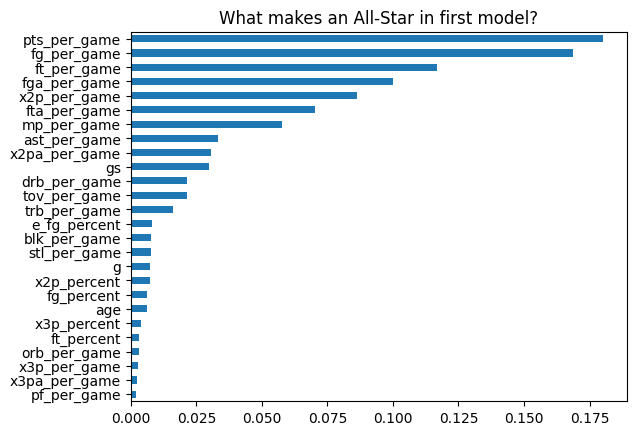

In [158]:

importances = pd.Series(model_first.feature_importances_, index=features.drop(['vorp', 'usg_percent', 'ws_48', 'as_legacy']))
importances.sort_values().plot(kind='barh', title='What makes an All-Star in first model?')

<Axes: title={'center': 'What makes an All-Star in finalized model?'}>

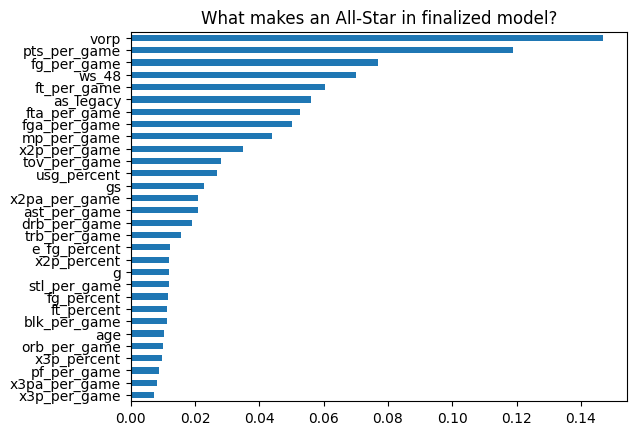

In [159]:
importances = pd.Series(best_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', title='What makes an All-Star in finalized model?')

## Evaluating Results for 2026 Season

In [160]:
# Get probabilities
probs = best_model.predict_proba(X_test)[:, 1]

# Attach to results
results = test__df[['player', 'AllStar']].copy()
results['Prob'] = probs

# Sort and pick the Top 24
results_2026 = results.sort_values(by='Prob', ascending=False)
results_2026['Predicted_AllStar'] = 0

# Count how many actual All-Stars there are in 2026, and that is how many AllStars our model will predict. This way our predictions are directly comparable to the actuals, since we know there are 24 All-Stars each season before replacement.
actual_all_stars_count = results_2026['AllStar'].sum()

results_2026.iloc[:actual_all_stars_2026_count, results_2026.columns.get_loc('Predicted_AllStar')] = 1




In [161]:
# Show accuracy, precision, recall, and F1 score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(results_2026['AllStar'], results_2026['Predicted_AllStar'])
precision = precision_score(results_2026['AllStar'], results_2026['Predicted_AllStar'])
recall = recall_score(results_2026['AllStar'], results_2026['Predicted_AllStar'])
f1 = f1_score(results_2026['AllStar'], results_2026['Predicted_AllStar'])

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.98
Precision: 0.81
Recall: 0.81
F1 Score: 0.81


Here we display the players that the model predicted to be AllStars that season. We choose the same amount of AllStars that were selected the year we are looking at. 

The amount should be 24, but injuries and replacements usually increase the amount by a couple. 

In [162]:
print(results_2026.head(actual_all_stars_2026_count)[['player', 'Prob', 'AllStar']])

                      player      Prob  AllStar
125  Shai Gilgeous-Alexander  0.781831        1
191             Nikola Jokić  0.742172        1
97               Luka Dončić  0.740896        1
221            Kawhi Leonard  0.738637        1
82           Cade Cunningham  0.711064        1
103             Kevin Durant  0.698749        1
242             Tyrese Maxey  0.696651        1
404        Victor Wembanyama  0.648880        1
44              Jaylen Brown  0.637861        1
263         Donovan Mitchell  0.627293        1
271             Jamal Murray  0.619217        1
9      Giannis Antetokounmpo  0.611547        1
187            Jalen Johnson  0.607063        1
107          Anthony Edwards  0.588140        1
143             James Harden  0.584533        0
46             Jalen Brunson  0.570699        1
83             Stephen Curry  0.544078        1
12               Deni Avdija  0.543372        1
377       Karl-Anthony Towns  0.487095        1
340           Alperen Şengün  0.478531  

In [163]:
# Display Actual All-Stars that the model missed 
print("ACTUAL ALL-STARS THE MODEL MISSED (RECALL ERRORS) ")
missed = results_2026[(results_2026['AllStar'] == 1) & (results_2026['Predicted_AllStar'] == 0)]
print(missed[['player', 'Prob']])

# Display Players the model picked who WEREN'T All-Stars (Precision Errors)
print("\nMODEL PICKS WHO WERE NOT ACTUAL ALL-STARS ")
false_positives = results_2026[(results_2026['AllStar'] == 0) & (results_2026['Predicted_AllStar'] == 1)]
print(false_positives[['player', 'Prob']])

ACTUAL ALL-STARS THE MODEL MISSED (RECALL ERRORS) 
             player      Prob
162   Chet Holmgren  0.269349
350   Pascal Siakam  0.269049
306   Norman Powell  0.231770
171  Brandon Ingram  0.192756
117    De'Aaron Fox  0.184804

MODEL PICKS WHO WERE NOT ACTUAL ALL-STARS 
                 player      Prob
143        James Harden  0.584533
15          LaMelo Ball  0.426579
300  Michael Porter Jr.  0.394647
110         Joel Embiid  0.389482
234     Lauri Markkanen  0.373558


# 8. Save the Model

Save the final dataset with predictions for future analysis

In [164]:

player_stats_cleaned = df
player_stats_cleaned.to_csv("..//datasets//player_stats_with_predictions.csv", index=False)

Save the best model

In [165]:
import joblib

joblib.dump(best_model, '..//models//best_all_star_predictor.pkl')

['..//models//best_all_star_predictor.pkl']

# 9. Future Improvements

After evaluation, we see that the model only correctly selected 22 out of 27 All Star players for the 2026 season. Some information that we believe can improve the model is the following: 
* Team Success: Sometimes players are on such great teams that their stats take a hit. However, these players are still regularly recognized, as most 1st seeds usually see at least 2 all star selections
* Market Size and Nationally televised games: Adding featrues that account for team market size or amount of nationally televised games could help the model account for players that have a higher visibilty from the public
* Ensemble Stacking: Instead of only Random Forest, we could implement a Stacking Classifier that would train multiple models and combine thier predictions for higher accuracy
* Conference Constraints: Adding a limit to the amount of players from each conference ( theretically would be 12 for the west and 12 for the east), would help improve accuracy


After working with these models, we still believe it would be nearly impossible to create a perfect model as there are many more variables that will always impact how these AllStars are selected. From player storylines to an influx of star players at a certain position, there are always years where certain players make the cut or when players are snubbed that do not make sense to most fans. However, we can always work to improve these models as we gain access to new information and technology. 